# Project - Classification - Titanic

The goal is to predict whether or not a Titanic passenger survived based on attributes such as their age, sex, passenger class, where they embarked and so on. 

This is one of the projects that is available at [Kaggle](https://www.kaggle.com/). You can create an account at [Kaggle](https://www.kaggle.com/) and download the data from the [Titanic challenge](https://www.kaggle.com/c/titanic) page. The data train.csv and test.csv are also provided on Canvas.



Read the train and test data from the csv files:

In [2]:
import pandas as pd

train_csv_path = "train.csv"
test_csv_path = "test.csv"

train_data = pd.read_csv(train_csv_path)
test_data = pd.read_csv(test_csv_path)


__The attributes and their meaning are as follows:__
- Survived: that's the target, 0 means the passenger did not survive, while 1 means he/she survived.
- Pclass: passenger class.
- Name, Sex, Age: self-explanatory
- SibSp: how many siblings & spouses of the passenger aboard the Titanic.
- Parch: how many children & parents of the passenger aboard the Titanic.
- Ticket: ticket id
- Fare: price paid (in pounds)
- Cabin: passenger's cabin number
- Embarked: where the passenger embarked the Titanic


##  Question 1:
_10 points_

Use head, tail, info, describe, value_counts methods to get insights about the data. Briefly describe 5 insights that you get by reviewing the data

### Answer #1: 
**Head:** Using `head()` gave me initial confirmation of the data being properly extracted from the beginning of the csv file. Additionally, passing the n-parameter allowed me to search as far as I wanted, allowing me to briefly preview, not entirely, potential missing data to mentally consider/anticipate for cleaning. I did `head()` on the first 20 data values. Some insights from head allowed me to anticipate `Age` requiring cleaning and `Cabin` aswell. Cabin showed significantly higher NaN values (15/20), hinting that cabin number may not be a reliable source for generalizing if cabin location could contribute to survival. Additionally, age was sparsely non-present (NaN: 3/20), meaning it could perhaps be unreliable and would require cleaning aswell. In short, head() gave an early preview of patterns in the data which may be present further on. 

**Tail** Similar to head, `tail()` allowed me to view the last n-parameter rows. It allowed me to verify that the data was properly extracted up to the end. I chose n=20 again. Some insights at the end also indicated/somewhat-confirmed unreliable cabin numbers (NaN: 15/20) and age discrepancies (NaN: 2/20). This insight again makes it clear what must be expected for cleaning.

**Info** `info()` provides a useful display of data types by column names. Counting the amount of dtypes present (5 ints, 5 objects, and 2 floats) and how many in each attribute contains non null type, it allowed us to confirm the amount of discrepancies in the data. Insights include `Age` and `Cabin` containing 714/891 and 204/891 fulfiled cells. Additionally `Embarked` with 889/891. This tells us that cabin number is significantly lacking filled values, age moderately, and embarked slightly. Cabin should be further researched prior to making generalizations to the entire population, perhaps removing the entire attribute would be the best option to minimize noise. Considering the moderate missing values, Age's missing values may be substitued with the median age and perhaps classified into discrete variables. The Embarked column's missing rows may be dropped, assuming they'd probably have minimlal effect.

**Describe** `describe` gives a statistical summary of each numerical attribute; int or float dtype in our case. Immediately what stands out is the mean survival at 38%, revealing that the data is unbalanced and biased for non-survivors. Therefore, accuracy alone, as discussed in class, may not be a completely valid measure for evaluating the model alone. Additionally, we see 177 missing values for age while all other numerical values are complete (891/891). As the lecture suggests, we could use a confusion matrix to evaluate the model. Additionally, another insight gathered is that the `Fare` mean (32) is higher than the median (14) with a maximum of 512, indicating significant right skewing; therefore we should account for outliers via an imputation (e.g. median of the fares).

**value_counts** `value_counts` shows the counts of unique values in a column (the frequency distribution). To get more specific insights, we may group specific attributes. I chose to group `Sex` with `Survival`, further indicating that there are significantly more males (577) onboard than females (314). The majority of females survived (74%) whereas the majority of men did not (19% survived), with more survivors being female, therefore insighting that gender may be a significant predictor for survival.


In [3]:
train_data.head(20) # gives me the first 20 rows (or n desired), verifying the training data was passed properly and
# hinting at potential missing data to consider for cleaning

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
train_data.tail(20) # similarly gives me the desired last rows of the dataset, verifying I've reached the end or similarly hinting at 
# missing data requiring cleaning

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
873,874,0,3,"Vander Cruyssen, Mr. Victor",male,47.0,0,0,345765,9.0000,NaN,S
874,875,1,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.0000,NaN,C
875,876,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C
876,877,0,3,"Gustafsson, Mr. Alfred Ossian",male,20.0,0,0,7534,9.8458,NaN,S
877,878,0,3,"Petroff, Mr. Nedelio",male,19.0,0,0,349212,7.8958,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S


In [5]:
train_data.info() # info provides summary of all non-null types and their data types.  non-null count provides how many were counted for the column
# hinting at how many are missing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
train_data.describe() # gives the a summary of the statistics, including only float and integer dtypes

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
train_data.groupby("Sex")["Survived"].value_counts() # tells us counts of unique instances, specific grouping is insightful such as 
# sex and survived

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

In [8]:
train_data.value_counts()

PassengerId  Survived  Pclass  Name                                                 Sex     Age   SibSp  Parch  Ticket    Fare     Cabin        Embarked
2            1         1       Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.0  1      0      PC 17599  71.2833  C85          C           1
4            1         1       Futrelle, Mrs. Jacques Heath (Lily May Peel)         female  35.0  1      0      113803    53.1000  C123         S           1
7            0         1       McCarthy, Mr. Timothy J                              male    54.0  0      0      17463     51.8625  E46          S           1
11           1         3       Sandstrom, Miss. Marguerite Rut                      female  4.0   1      1      PP 9549   16.7000  G6           S           1
12           1         1       Bonnell, Miss. Elizabeth                             female  58.0  0      0      113783    26.5500  C103         S           1
                                                         

In [9]:
train_data["Pclass"].value_counts(normalize=True) # added this because it is helpful for further analysis (#3)

Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64

## Question 2:

_8 points_

Prepare a DataFrame that contains the following numeric fields: Survided, Sex, Age, SibSp, Parch, Fare. Plot these numeric fields on a histogram to get more insights. Share at least two insights.


### Answer #2:
**1st Insight**: As mentioned earlier, there are significantly more non-survivors than survivors. This insight shows the data is unbalanced, favoring non-survivors and the model shouldn't confidently rely on accuracy. 

**2nd Insight**: The second insight regards Fare prices. The histogram shows that fare prices with the most passengers ranged from 0-50 pounds with a right skew where a fare reached a maximum over 500. Beyond 50 pounds, there is a smaller subset of passengers who paid more, indicating a difference between economic classes that should be accounted for when considering survival.

**3rd Insight**: The Age histogram shows that the age group with the most passengers is between 20 and 30 years old. This tells us that young adults made up the largest portion of the data. This indicates an uneven distribution of ages that may mislead accuracy interpretations for smaller age groups.

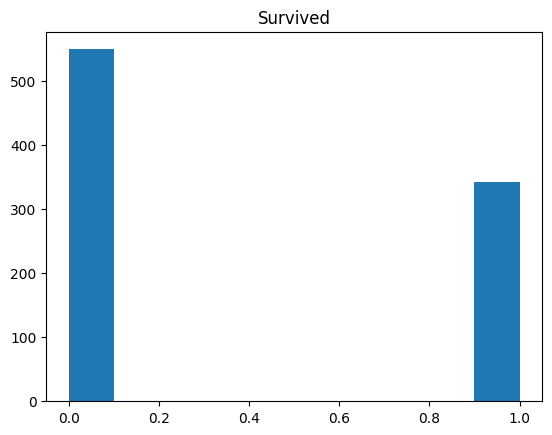

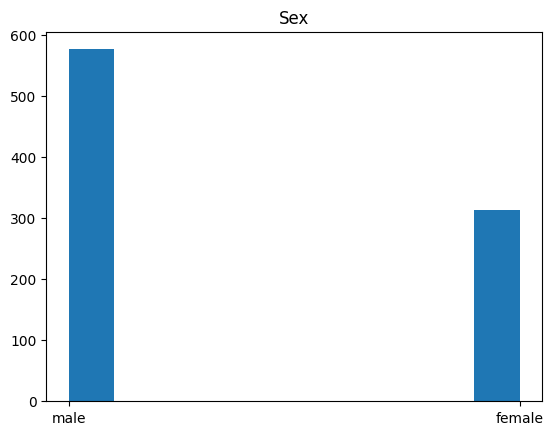

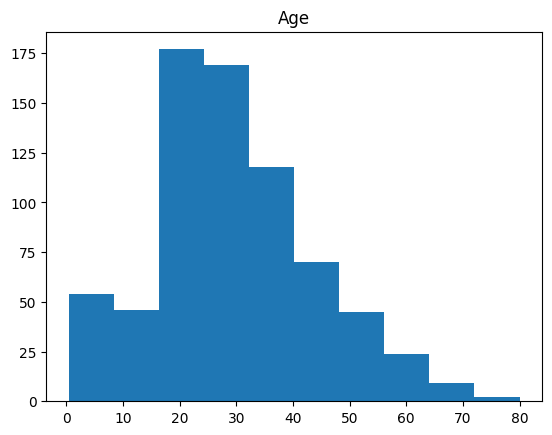

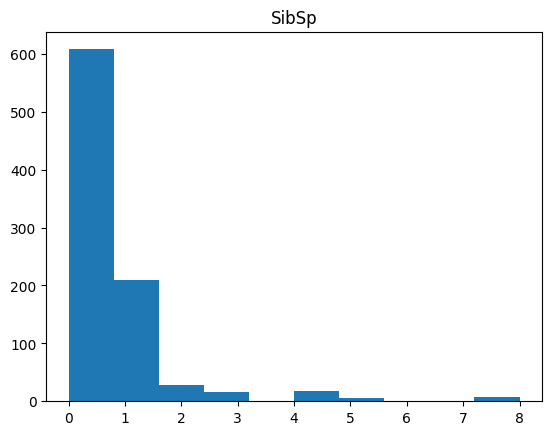

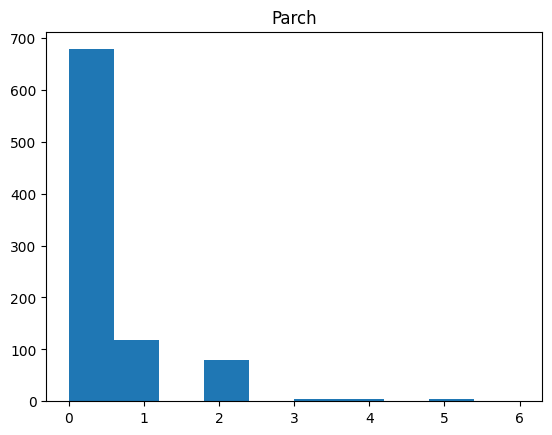

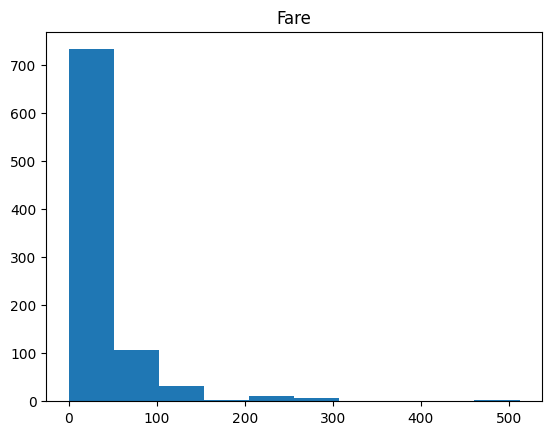

'\nplt.hist(select_df["Survived"])\nplt.title("Survived") \nplt.show()\n\nplt.hist(select_df["Sex"], bins = 5)\nplt.title("Sex") \nplt.show()\n\nplt.hist(select_df["Age"])\nplt.title("Age") \nplt.show()\n\nplt.hist(select_df["SibSp"])\nplt.title("SibSp") \nplt.show()\n\nplt.hist(select_df["Parch"])\nplt.title("Parch") \nplt.show()\n'

In [10]:
# self note:
# prepare DataFrame, contains Survived, Sex, Age, SibSp, Parch, Fare. Plot onto a histogram (probably via matplotlib)

import matplotlib.pyplot as plt
attributes = ["Survived", "Sex", "Age", "SibSp", "Parch", "Fare"]
select_df = train_data[attributes] # pass the attributes into the data frame

for col in attributes:
    plt.hist(select_df[col])
    plt.title(col)
    plt.show()

'''
plt.hist(select_df["Survived"])
plt.title("Survived") 
plt.show()

plt.hist(select_df["Sex"], bins = 5)
plt.title("Sex") 
plt.show()

plt.hist(select_df["Age"])
plt.title("Age") 
plt.show()

plt.hist(select_df["SibSp"])
plt.title("SibSp") 
plt.show()

plt.hist(select_df["Parch"])
plt.title("Parch") 
plt.show()
'''


## Question 3: 

_8 points_

Show the average survival rate based on passenger class and then based on sex. Then plot the results for each. What insights do you get? Name at least one for each plot.

The following examples use group by and plot:

    dataFrame.groupby(‘attribute1’)[‘attribute2’].mean()

    dataFrame.groupby(‘attribute1’)[‘attribute2’].mean().plot(kind=’bar’)

For more information about how to use these functions, study the followings:
https://towardsdatascience.com/pandas-groupby-explained-453692519d0

https://medium.com/@sciencelee/making-plots-with-the-pandas-groupby-ac492941af28


### Answer #3:

**Plot 1 Insight:** From observing the bar chart, the passenger class with the highest survival rate was class 1, telling us that passenger class may be a significant predictor. However, it is important to note that class 1 is represented by less than 25% of the ship's passengers, therefore the model's experience may not align as much with class 1 and more with 3 (55%), demonstrating a nonrepresentative training data challenge.
**Plot 2 Insight:** Observing average survival rate based on sex, it appears that females have slightly over 70% whereas men slightly below 20%. This tells us that being a female could be a strong indicator of surviving the Titanic.


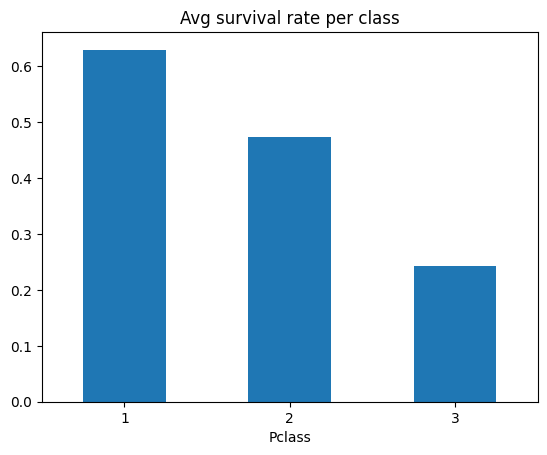

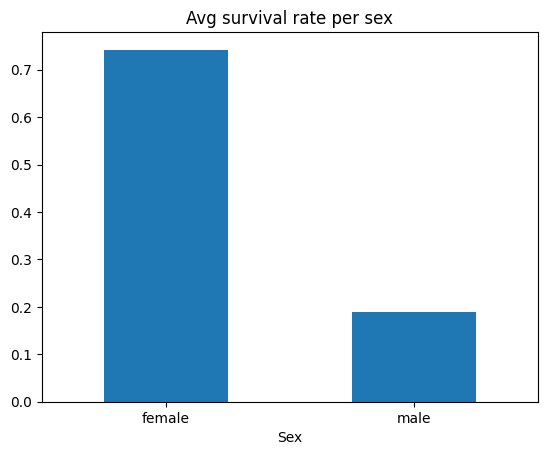

In [11]:
# self notes:
# show avg survival rate for Pclass

train_data.groupby("Pclass")["Survived"].mean()
train_data.groupby("Pclass")["Survived"].mean().plot(kind='bar')
plt.xticks(rotation=0) # to flip the independent variables on the x-axis; they automatically faced downward
plt.title("Avg survival rate per class")
plt.show()
# show avg survival rate for sex

select_df.groupby("Sex")["Survived"].mean()
select_df.groupby("Sex")["Survived"].mean().plot(kind='bar')
plt.xticks(rotation=0)
plt.title("Avg survival rate per sex")
plt.show()

__The following code does the followings:__
- Create a new 'all_data' frame by appending test data to train data.
- Check missing values using info() method

In [12]:
all_data = pd.concat([train_data, test_data], ignore_index=True)
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


## Question 4:

_12 points_

Fill in the columns with missing data (null values) using a 'NA' text or median or mode (most frequent) or anything that makes sense (explain your reasoning).

### Answer #4: 
+ **Survived** Off initial glance it may be tempting to adjust `Survived`, but it is important we do not because it is our target attribute. It is at 891 non-null because it is the train set and the model does not have labels for the test set yet.
+ **Age** Considering Age is moderately missing values, we may fill in values using the median. This is a good strategy because the age of the passengers is skewed already, therefore a median can be used to demonstrate the best measure of central tendency.
+ **Cabin** Considering Cabin is significantly missing data (~77%), we may consider discarding the entire column. Including a low occupied column wouldn't be representative enough of the passengers when testing the model.
+ **Embarked** Considering Embarked is almost full and is missing 2 values, we may substitue the missing values with the mode. The mode works well because it is a measure of tendency that could work with categorical data (e.g. C,S,Q). Additionally, embarked status does not have a median or mean considering it is non-numerical.

In [13]:
# self note: 
# fill/adjust all_data columns: Age, Cabin, Embarked

# first discard cabin

all_data = all_data.drop("Cabin", axis = 1)

# fill Age with median
median = all_data["Age"].median()
all_data["Age"] = all_data["Age"].fillna(median)
#all_data["Age"].fillna(median, inplace = True)

# fill Embarked with mode
mode = all_data["Embarked"].value_counts().idxmax()
all_data["Embarked"] = all_data["Age"].fillna(mode)
#all_data["Embarked"].fillna(mode, inplace = True)

## Question 5:

_4 points_

Create a new feature 'Family_Size'
- Create a new feature 'Family_Size' using other features (and also adding the person him/herself to the family size). 
- Then plot a bar chart to show how many of each 'Family_Size' value exists. 
- Finally plot a bar chart to show the relationship between 'Family_Size' and the 'Survival' 

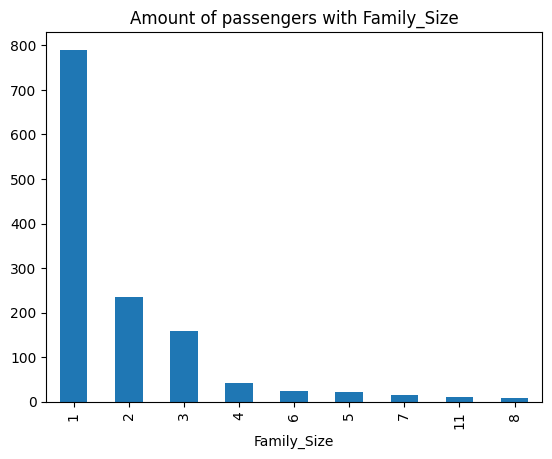

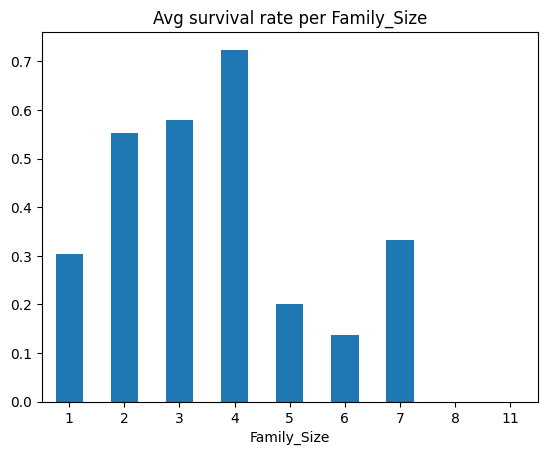

In [14]:
# self note:
# create feature 'Family Size' including individual in count
# plot how many family size exist
# plot family size vs survival

# Family_Size = parch + SibSp

all_data["Family_Size"] = all_data["Parch"] + all_data["SibSp"] + 1 # +1 to include self

all_data["Family_Size"].value_counts().plot(kind='bar')
plt.title("Amount of passengers with Family_Size")
plt.show()

all_data.groupby("Family_Size")["Survived"].mean()
all_data.groupby("Family_Size")["Survived"].mean().plot(kind='bar')
plt.xticks(rotation=0) # to flip the independent variables on the x-axis; they automatically faced downward
plt.title("Avg survival rate per Family_Size")
plt.show()

## Question 6:

_3 points_

Suggest another new feature that might help. You do not need to implement it. Briefly explain why it might help.


### Answer #6: 
Another feature that might help could combine Pclass and Sex. I believe it might help because Pclass, as being likely correlated to wealth or social class, could perhaps make a high predictor for survivability when combined with gender. Survival rates may be different for sex depending on what social class they were in.

__Using One Hot Encoder to create new numeric features from categorical features__
Use the following function to create new attributes and then concatenate new attributes with the all_data dataframe.

The following method takes a dataframe and a feature name and then returns a dataframe with one-hot-encoded columns:

The code is adapted from the following article: 
- https://towardsdatascience.com/machine-learning-with-the-titanic-dataset-7f6909e58280

In [15]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

def encode_category_to_numeric(feature,data_frame):
  encoded_feat = OneHotEncoder().fit_transform(data_frame[feature].values.reshape(-1,1)).toarray()
  #number_unique = data_frame[feature].nunique()
  unique_values = data_frame[feature].unique()
  sorted_unique_value = np.sort(unique_values)
  cols = ['{}_{}'.format(feature,value) for value in sorted_unique_value]
  encoded_data = pd.DataFrame(encoded_feat, columns=cols)
  return encoded_data

__Creation of new attributes for the 'Embarked' attribute__

In [16]:
encoded_data = encode_category_to_numeric('Embarked',all_data)
all_data = pd.concat([all_data, encoded_data], axis=1)
encoded_data.info()
all_data.info()
all_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 98 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Embarked_0.17  1309 non-null   float64
 1   Embarked_0.33  1309 non-null   float64
 2   Embarked_0.42  1309 non-null   float64
 3   Embarked_0.67  1309 non-null   float64
 4   Embarked_0.75  1309 non-null   float64
 5   Embarked_0.83  1309 non-null   float64
 6   Embarked_0.92  1309 non-null   float64
 7   Embarked_1.0   1309 non-null   float64
 8   Embarked_2.0   1309 non-null   float64
 9   Embarked_3.0   1309 non-null   float64
 10  Embarked_4.0   1309 non-null   float64
 11  Embarked_5.0   1309 non-null   float64
 12  Embarked_6.0   1309 non-null   float64
 13  Embarked_7.0   1309 non-null   float64
 14  Embarked_8.0   1309 non-null   float64
 15  Embarked_9.0   1309 non-null   float64
 16  Embarked_10.0  1309 non-null   float64
 17  Embarked_11.0  1309 non-null   float64
 18  Embarked

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked_64.0,Embarked_65.0,Embarked_66.0,Embarked_67.0,Embarked_70.0,Embarked_70.5,Embarked_71.0,Embarked_74.0,Embarked_76.0,Embarked_80.0
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


__Creation of new attributes for the 'Pclass' attribute and then concatenate new attributes with the all_data dataframe__

In [17]:
encoded_data = encode_category_to_numeric('Pclass',all_data)
all_data = pd.concat([all_data, encoded_data], axis=1)
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Columns: 113 entries, PassengerId to Pclass_3
dtypes: float64(105), int64(5), object(3)
memory usage: 1.1+ MB


__Using LabelEncoder, create the 'Sex_Numeric' based on the values of the 'Sex' attribute__

In [18]:
from sklearn.preprocessing import LabelEncoder
all_data['Sex_Numeric'] = LabelEncoder().fit_transform(all_data['Sex'])
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Columns: 114 entries, PassengerId to Sex_Numeric
dtypes: float64(105), int64(6), object(3)
memory usage: 1.1+ MB


In [19]:
all_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked_70.0,Embarked_70.5,Embarked_71.0,Embarked_74.0,Embarked_76.0,Embarked_80.0,Pclass_1,Pclass_2,Pclass_3,Sex_Numeric
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1


## Question 7:

_8 points_

Create a dataframe that includes only numeric attribures of all_data and name it as all_data_numeric. Then calculate/find the correlations between the 'survided' field and other numeric fields.

In [20]:
# self note: 
# create data frame, includes only numeric attributes. name it all_data_numeric
# this excludes: name, sex, ticket

numeric_attributes = ["PassengerId", "Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "Pclass_1", "Pclass_2", "Pclass_3", "Sex_Numeric"]

embarked_cols = [col for col in all_data.columns if "Embarked_" in col]
final_attributes = numeric_attributes + embarked_cols
all_data_numeric = all_data[final_attributes]  # add embarked afterward

all_data_numeric.head() # used to verify our data was extracted properly

# now we calc the correlations b/w survived & other numerics

corr_matrix = all_data_numeric.corr()

survival_correlations = corr_matrix["Survived"].sort_values(ascending=False)
print(survival_correlations)


Survived         1.000000
Pclass_1         0.285904
Fare             0.257307
Pclass_2         0.093349
Embarked_5.0     0.085083
                   ...   
Embarked_26.5         NaN
Embarked_38.5         NaN
Embarked_60.5         NaN
Embarked_67.0         NaN
Embarked_76.0         NaN
Name: Survived, Length: 109, dtype: float64


## Question 8:

_8 points_

Based on the correlation matrix results, identify some of the features as unimportant and drop them. Also drop the non-numeric fields. Assign the remaining DataFrame to the variable named 'important_data'.  When you drop features, leave at least 10 columns besides 'Survided' in the 'important_data' DataFrame. After that, check the correlation to 'Survived' as you did before.

## Question 9:

_9 points_

Create X_train, Y_train and X_test DataFrames. 
- X_train should have 891 instances from 'important_data' data frame and the rest should go to X_test. 
- Drop the 'Survived' from X_test. Check the X_train, X_test and Y_train.

## Question 10:

_21 points_

For each of the algorithms, use Scikit-Learn's cross-validation feature to measure the performance and print out mean and std for each algoritm:

1. Stochastic Gradient Descent (SGD)
2. LogisticRegression
3. Support Vector Machine (kernel='linear' parameter)
4. DecisionTreeClassifier
5. RandomForestClassifier
6. AdaBoostClassifier
7. GradientBoostingClassifier

Parameters:
- Set the scoring parameter of cross-validation to 'f1'
- Use the default cv = 5 parameter of cross-validation
- Use random_state = 42 for initializing model algorithms
- Use the kernel parameter indicated above for SVM algorithms
- Use a solver parameter that works for the logistic regression
- For others, use the default parameters (no need to specify explicitly)

After using cross_val_score function to train and get scores, print mean and std for the score.

In [ ]:
random_seed = 42
scoring_parameter = "f1"
k_fold = 5
from sklearn.model_selection import cross_val_score

## Question 11:

_16 points_

Select the top 3 best performing classifiers. List them along with their mean and std scores. For these top 3 best performing classifiers, find the best hyperparameters using GridSearchCV.

- Use estimator.get_params().keys() or the API description of the classifiers to find out which hyperparameters you can use. 
- Use the same scoring parameter ('f1') and use cv = 10 this time. 
- Print out the best_estimator_ and best_score_ results of your Grid Search
- Use the following hyparparameter options if they fit for your top 3 classifiers:

n_estimators = [300, 400, 500]

learning_rate = [0.3, 0.1, 0.05]

max_features =  [1, 0.5, 0.3]

subsample = [1, 0.5, 0.3]

max_samples = [1, 0.5, 0.3]

bootstrap = [True]

criterion = ['gini', 'entropy', 'log_loss']

max_depth = [None, 3, 5, 10, 20]


In [ ]:

n_estimators = [300, 400, 500]
learning_rate = [0.3, 0.1, 0.05]
max_features =  [1, 0.5, 0.3]
subsample = [1, 0.5, 0.3]
max_samples = [1, 0.5, 0.3]
bootstrap = [True]
criterion = ['gini', 'entropy', 'log_loss']
max_depth = [None, 3, 5, 10, 20]
k_fold = 10

from sklearn.model_selection import GridSearchCV


## Question 12

_8 points_

Use VotingClassifier of sklearn to create an ensemble learner that utilizes the top 3 estimators you found above. 
- Set the voting parameter to 'soft'.
- Use cross_val_score to calculate its score and print out its mean and std values.
  
Then use the VotingClassifier you created to predict 'Survived' for the X_test.

The following page might be useful:

Kaggl Titanic: A Machine Learning from Disaster | Modelling Part 2: 
https://www.codementor.io/@innat_2k14/kaggl-titanic-a-machine-learning-from-disaster-modelling-part-2-10gfjtm0p3

In [ ]:
from sklearn.ensemble import VotingClassifier